# **Processos usados para Análise de Densidade Urbana**





# Baixar dados TIFF de densidade demográfica e edilicia do GHSL

Densidade Demográfica:

Densidade Edilicia: https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_BUILT_S_GLOBE_R2023A/

Densidade Demográfica: https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/

Foram baixados os dados de: 1980, 1990, 2000, 2010 e 2020.

Os dados considerados foram em pixels de 100x100m

Ex: 	GHS_POP_E1980_GLOBO_R2023A_54009_100/

Após baixar os dados, foi usado o QGis para recortar o poligono do municipio de Blumenau.

O TIFF resultante foi tratado dentro do QGis por meio da ferramenta simbologia para gerar os mapas de densidade demográfica e edilicia.

Os TIFFs foram salvos e utilizados para extrair as informações de densidades para as tabelas conforme os codigos que seguem.

As cotas de enchente utilizadas para a análise estão disponíveis em: https://labgeo.furb.br/catalogue/#/detail/dataset/26?f=dataset



In [ ]:
# Primeiro, instale as bibliotecas necessárias
!pip install rasterio
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 49.4 MB/s eta 0:00:00


In [ ]:
import rasterio
import geopandas as gpd

# Caminhos dos arquivos
tiff_paths = {
    "densidade_edilicia": "/content/bnu_edificios_1980_reprojetado.tif",
    "densidade_populacional": "/content/bnu_pop_1980_reprojetado.tif"
}

shapefile_paths = {
    "rio": "/content/shapefile_rio_utm_22s.shp",
    "cota_7": "/content/blumenau_cartaenchente7m.shp",
    "cota_10": "/content/blumenau_cartaenchente10m.shp",
    "cota_13": "/content/blumenau_cartaenchente13m.shp"
}

# Função para extrair o código EPSG de arquivos TIFF
def get_tiff_epsg(path):
    with rasterio.open(path) as src:
        return src.crs.to_epsg()

# Função para extrair o código EPSG de Shapefiles
def get_shapefile_epsg(path):
    gdf = gpd.read_file(path)
    return gdf.crs.to_epsg()

# Coletando os códigos EPSG para cada arquivo
epsg_codes = {key: get_tiff_epsg(path) for key, path in tiff_paths.items()}
epsg_codes.update({key: get_shapefile_epsg(path) for key, path in shapefile_paths.items()})

print(epsg_codes)

{'densidade_edilicia': 31982, 'densidade_populacional': 31982, 'rio': 31982, 'cota_7': 4326, 'cota_10': 4326, 'cota_13': 4326}


# Tabela 1980

In [ ]:
# Instalação das bibliotecas necessárias
!pip install geopandas

import geopandas as gpd
from pyproj import CRS

# Caminhos para os arquivos Shapefile de cota de enchente
shapefiles = {
    "cota_7": "/content/blumenau_cartaenchente7m.shp",
    "cota_10": "/content/blumenau_cartaenchente10m.shp",
    "cota_13": "/content/blumenau_cartaenchente13m.shp"
}

# Definir o CRS de destino para EPSG 31982
target_crs = CRS('EPSG:31982')

# Função para reprojeto e salvar Shapefiles
def reproject_save_shapefile(input_path, output_path):
    # Carregar o Shapefile
    gdf = gpd.read_file(input_path)

    # Reprojetar o GeoDataFrame
    gdf_reprojected = gdf.to_crs(target_crs)

    # Salvar o GeoDataFrame reprojeto
    gdf_reprojected.to_file(output_path)

# Iterar sobre os arquivos de cota, reprojeto e salvar com novos nomes
for key, path in shapefiles.items():
    output_path = path.replace(".shp", "_reprojected.shp")
    reproject_save_shapefile(path, output_path)


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import pandas as pd
from tqdm import tqdm

# Caminhos para osrquivos
tiff_edilicio = "/content/bnu_edificios_1980_reprojetado.tif"
tiff_demografico = "/content/bnu_pop_1980_reprojetado.tif"
shapefile_cota_7m = "/content/blumenau_cartaenchente7m_reprojected.shp"
shapefile_cota_10m = "/content/blumenau_cartaenchente10m_reprojected.shp"
shapefile_cota_13m = "/content/blumenau_cartaenchente13m_reprojected.shp"
shapefile_rio = "/content/shapefile_rio_utm_22s.shp"

# Carregar os shapefiles
gdf_cota_7m = gpd.read_file(shapefile_cota_7m)
gdf_cota_10m = gpd.read_file(shapefile_cota_10m)
gdf_cota_13m = gpd.read_file(shapefile_cota_13m)
gdf_rio = gpd.read_file(shapefile_rio)

# Carregar o TIFF de densidade edilícia e demográfica
with rasterio.open(tiff_edilicio) as src_edilicio:
    densidade_edilicia = src_edilicio.read(1)
    transform_edilicio = src_edilicio.transform

with rasterio.open(tiff_demografico) as src_demografico:
    densidade_demografica = src_demografico.read(1)
    transform_demografico = src_demografico.transform

# Função para verificar se um pixel é atingido por um shapefile
def pixel_atingido_por_shape(pixel_coords, gdf_shape):
    ponto = Point(pixel_coords)  # Criar um ponto a partir das coordenadas do pixel
    return any(gdf_shape.contains(ponto))

# Inicializar lista para armazenar os resultados
resultados = []

total_pixels = densidade_edilicia.shape[0] * densidade_edilicia.shape[1]
progress = tqdm(total=total_pixels, desc="Processando pixels")

# Iterar sobre cada pixel do TIFF
for row in range(densidade_edilicia.shape[0]):
    for col in range(densidade_edilicia.shape[1]):
        pixel_coords = rasterio.transform.xy(transform_edilicio, row, col, offset='center')
        densidade_edil = densidade_edilicia[row, col]
        densidade_demo = densidade_demografica[row, col]

        # Verificações
        atingido_rio = pixel_atingido_por_shape(pixel_coords, gdf_rio)
        atingido_7m = pixel_atingido_por_shape(pixel_coords, gdf_cota_7m)
        atingido_10m = pixel_atingido_por_shape(pixel_coords, gdf_cota_10m)
        atingido_13m = pixel_atingido_por_shape(pixel_coords, gdf_cota_13m)

        resultados.append({
            'Coordenada_X': pixel_coords[0],
            'Coordenada_Y': pixel_coords[1],
            'Ano': 1980,
            'Densidade_Edilicia': densidade_edil,
            'Densidade_Demografica': densidade_demo,
            'Atingido_Rio': atingido_rio,
            'Cota_7m': atingido_7m,
            'Cota_10m': atingido_10m,
            'Cota_13m': atingido_13m
        })

        progress.update(1)

progress.close()

# Converter os resultados em um DataFrame pandas
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame em um arquivo CSV
df_resultados.to_csv("/content/resultados_cheias_1980.csv", index=False)

print("Tabela gerada e salva como resultados_cheias_1980.csv")


Processando pixels: 100%|██████████| 256400/256400 [07:23<00:00, 578.48it/s] 


Tabela gerada e salva como resultados_cheias_1980.csv


# Tabela 1990

# Nova seção

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling

def reproject_tiff(input_path, output_path, dst_crs):
    # Abrir o TIFF de entrada
    with rasterio.open(input_path) as src:
        # Coletar transformações e metadados
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        # Atualizar o perfil do arquivo para o novo CRS
        profile = src.profile
        profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Abrir o arquivo de saída e reprojetar
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )

# Caminho para os TIFFs de densidade edilícia e demográfica
input_tiff_edilicia = "/content/blumenau_edificios_1990.tif"
output_tiff_edilicia = "densidade_edilicia_reprojetado.tif"
input_tiff_demografica = "/content/blumenau_pop_1990.tif"
output_tiff_demografica = "densidade_demografica_reprojetado.tif"

# Definindo o novo sistema de referência espacial EPSG:31982
dst_crs = 'EPSG:31982'

# Reprojetar os TIFFs
reproject_tiff(input_tiff_edilicia, output_tiff_edilicia, dst_crs)
reproject_tiff(input_tiff_demografica, output_tiff_demografica, dst_crs)

print("Reprojeção concluída.")


RasterioIOError: /content/blumenau_edificios_1990.tif: No such file or directory

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import pandas as pd
from tqdm import tqdm

# Caminhos para os arquivos
tiff_edilicio = "/content/densidade_edilicia1990_reprojetado.tif"
tiff_demografico = "/content/densidade_demografica1990_reprojetado.tif"
shapefile_cota_7m = "/content/blumenau_cartaenchente7m_reprojected.shp"
shapefile_cota_10m = "/content/blumenau_cartaenchente10m_reprojected.shp"
shapefile_cota_13m = "/content/blumenau_cartaenchente13m_reprojected.shp"
shapefile_rio = "/content/shapefile_rio_utm_22s.shp"

# Carregar os shapefiles
gdf_cota_7m = gpd.read_file(shapefile_cota_7m)
gdf_cota_10m = gpd.read_file(shapefile_cota_10m)
gdf_cota_13m = gpd.read_file(shapefile_cota_13m)
gdf_rio = gpd.read_file(shapefile_rio)

# Carregar o TIFF de densidade edilícia e demográfica
with rasterio.open(tiff_edilicio) as src_edilicio:
    densidade_edilicia = src_edilicio.read(1)
    transform_edilicio = src_edilicio.transform

with rasterio.open(tiff_demografico) as src_demografico:
    densidade_demografica = src_demografico.read(1)
    transform_demografico = src_demografico.transform

# Função para verificar se um pixel é atingido por um shapefile
def pixel_atingido_por_shape(pixel_coords, gdf_shape):
    ponto = Point(pixel_coords)  # Criar um ponto a partir das coordenadas do pixel
    return any(gdf_shape.contains(ponto))

# Inicializar lista para armazenar os resultados
resultados = []

total_pixels = densidade_edilicia.shape[0] * densidade_edilicia.shape[1]
progress = tqdm(total=total_pixels, desc="Processando pixels")

# Iterar sobre cada pixel do TIFF
for row in range(densidade_edilicia.shape[0]):
    for col in range(densidade_edilicia.shape[1]):
        pixel_coords = rasterio.transform.xy(transform_edilicio, row, col, offset='center')
        densidade_edil = densidade_edilicia[row, col]
        densidade_demo = densidade_demografica[row, col]

        # Verificações
        atingido_rio = pixel_atingido_por_shape(pixel_coords, gdf_rio)
        atingido_7m = pixel_atingido_por_shape(pixel_coords, gdf_cota_7m)
        atingido_10m = pixel_atingido_por_shape(pixel_coords, gdf_cota_10m)
        atingido_13m = pixel_atingido_por_shape(pixel_coords, gdf_cota_13m)

        resultados.append({
            'Coordenada_X': pixel_coords[0],
            'Coordenada_Y': pixel_coords[1],
            'Ano': 1990,
            'Densidade_Edilicia': densidade_edil,
            'Densidade_Demografica': densidade_demo,
            'Atingido_Rio': atingido_rio,
            'Cota_7m': atingido_7m,
            'Cota_10m': atingido_10m,
            'Cota_13m': atingido_13m
        })

        progress.update(1)

progress.close()

# Converter os resultados em um DataFrame pandas
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame em um arquivo CSV
df_resultados.to_csv("/content/resultados_cheias_1990.csv", index=False)

print("Tabela gerada e salva como resultados_cheias_1990.csv")


Processando pixels: 100%|██████████| 256400/256400 [07:04<00:00, 604.62it/s] 


Tabela gerada e salva como resultados_cheias_1990.csv


# Tabela 2000

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling

def reproject_tiff(input_path, output_path, dst_crs):
    # Abrir o TIFF de entrada
    with rasterio.open(input_path) as src:
        # Coletar transformações e metadados
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        # Atualizar o perfil do arquivo para o novo CRS
        profile = src.profile
        profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Abrir o arquivo de saída e reprojetar
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )

# Caminho para os TIFFs de densidade edilícia e demográfica
input_tiff_edilicia = "/content/blumenau_edificios_2000.tif"
output_tiff_edilicia = "densidade_edilicia2000_reprojetado.tif"
input_tiff_demografica = "/content/blumenau_pop_2000.tif"
output_tiff_demografica = "densidade_demografica2000_reprojetado.tif"

# Definindo o novo sistema de referência espacial EPSG:31982
dst_crs = 'EPSG:31982'

# Reprojetar os TIFFs
reproject_tiff(input_tiff_edilicia, output_tiff_edilicia, dst_crs)
reproject_tiff(input_tiff_demografica, output_tiff_demografica, dst_crs)

print("Reprojeção concluída.")

Reprojeção concluída.


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import pandas as pd
from tqdm import tqdm

# Defina os caminhos para os  arquivos
tiff_edilicio = "/content/densidade_edilicia2000_reprojetado.tif"
tiff_demografico = "/content/densidade_demografica2000_reprojetado.tif"
shapefile_cota_7m = "/content/blumenau_cartaenchente7m_reprojected.shp"
shapefile_cota_10m = "/content/blumenau_cartaenchente10m_reprojected.shp"
shapefile_cota_13m = "/content/blumenau_cartaenchente13m_reprojected.shp"
shapefile_rio = "/content/shapefile_rio_utm_22s.shp"

# Carregar os shapefiles
gdf_cota_7m = gpd.read_file(shapefile_cota_7m)
gdf_cota_10m = gpd.read_file(shapefile_cota_10m)
gdf_cota_13m = gpd.read_file(shapefile_cota_13m)
gdf_rio = gpd.read_file(shapefile_rio)

# Carregar o TIFF de densidade edilícia e demográfica
with rasterio.open(tiff_edilicio) as src_edilicio:
    densidade_edilicia = src_edilicio.read(1)
    transform_edilicio = src_edilicio.transform

with rasterio.open(tiff_demografico) as src_demografico:
    densidade_demografica = src_demografico.read(1)
    transform_demografico = src_demografico.transform

# Função para verificar se um pixel é atingido por um shapefile
def pixel_atingido_por_shape(pixel_coords, gdf_shape):
    ponto = Point(pixel_coords)  # Criar um ponto a partir das coordenadas do pixel
    return any(gdf_shape.contains(ponto))

# Inicializar lista para armazenar os resultados
resultados = []

total_pixels = densidade_edilicia.shape[0] * densidade_edilicia.shape[1]
progress = tqdm(total=total_pixels, desc="Processando pixels")

# Iterar sobre cada pixel do TIFF
for row in range(densidade_edilicia.shape[0]):
    for col in range(densidade_edilicia.shape[1]):
        pixel_coords = rasterio.transform.xy(transform_edilicio, row, col, offset='center')
        densidade_edil = densidade_edilicia[row, col]
        densidade_demo = densidade_demografica[row, col]

        # Verificações
        atingido_rio = pixel_atingido_por_shape(pixel_coords, gdf_rio)
        atingido_7m = pixel_atingido_por_shape(pixel_coords, gdf_cota_7m)
        atingido_10m = pixel_atingido_por_shape(pixel_coords, gdf_cota_10m)
        atingido_13m = pixel_atingido_por_shape(pixel_coords, gdf_cota_13m)

        resultados.append({
            'Coordenada_X': pixel_coords[0],
            'Coordenada_Y': pixel_coords[1],
            'Ano': 2000,
            'Densidade_Edilicia': densidade_edil,
            'Densidade_Demografica': densidade_demo,
            'Atingido_Rio': atingido_rio,
            'Cota_7m': atingido_7m,
            'Cota_10m': atingido_10m,
            'Cota_13m': atingido_13m
        })

        progress.update(1)

progress.close()

# Converter os resultados em um DataFrame pandas
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame em um arquivo CSV
df_resultados.to_csv("/content/resultados_cheias_2000.csv", index=False)

print("Tabela gerada e salva como resultados_cheias_2000.csv")


Processando pixels: 100%|██████████| 256400/256400 [06:48<00:00, 627.72it/s] 


Tabela gerada e salva como resultados_cheias_2000.csv


# Tabela 2010

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling

def reproject_tiff(input_path, output_path, dst_crs):
    # Abrir o TIFF de entrada
    with rasterio.open(input_path) as src:
        # Coletar transformações e metadados
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        # Atualizar o perfil do arquivo para o novo CRS
        profile = src.profile
        profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Abrir o arquivo de saída e reprojetar
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )

# Caminho para os  TIFFs de densidade edilícia e demográfica
input_tiff_edilicia = "/content/blumenau_edificios_2010.tif"
output_tiff_edilicia = "densidade_edilicia2010_reprojetado.tif"
input_tiff_demografica = "/content/blumenau_pop_2010.tif"
output_tiff_demografica = "densidade_demografica2010_reprojetado.tif"

# Definindo o novo sistema de referência espacial EPSG:31982
dst_crs = 'EPSG:31982'

# Reprojetar os TIFFs
reproject_tiff(input_tiff_edilicia, output_tiff_edilicia, dst_crs)
reproject_tiff(input_tiff_demografica, output_tiff_demografica, dst_crs)

print("Reprojeção concluída.")

Reprojeção concluída.


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import pandas as pd
from tqdm import tqdm

# Defina os caminhos para os seus arquivos
tiff_edilicio = "/content/densidade_edilicia2010_reprojetado.tif"
tiff_demografico = "/content/densidade_demografica2010_reprojetado.tif"
shapefile_cota_7m = "/content/blumenau_cartaenchente7m_reprojected.shp"
shapefile_cota_10m = "/content/blumenau_cartaenchente10m_reprojected.shp"
shapefile_cota_13m = "/content/blumenau_cartaenchente13m_reprojected.shp"
shapefile_rio = "/content/shapefile_rio_utm_22s.shp"

# Carregar os shapefiles
gdf_cota_7m = gpd.read_file(shapefile_cota_7m)
gdf_cota_10m = gpd.read_file(shapefile_cota_10m)
gdf_cota_13m = gpd.read_file(shapefile_cota_13m)
gdf_rio = gpd.read_file(shapefile_rio)

# Carregar o TIFF de densidade edilícia e demográfica
with rasterio.open(tiff_edilicio) as src_edilicio:
    densidade_edilicia = src_edilicio.read(1)
    transform_edilicio = src_edilicio.transform

with rasterio.open(tiff_demografico) as src_demografico:
    densidade_demografica = src_demografico.read(1)
    transform_demografico = src_demografico.transform

# Função para verificar se um pixel é atingido por um shapefile
def pixel_atingido_por_shape(pixel_coords, gdf_shape):
    ponto = Point(pixel_coords)  # Criar um ponto a partir das coordenadas do pixel
    return any(gdf_shape.contains(ponto))

# Inicializar lista para armazenar os resultados
resultados = []

total_pixels = densidade_edilicia.shape[0] * densidade_edilicia.shape[1]
progress = tqdm(total=total_pixels, desc="Processando pixels")

# Iterar sobre cada pixel do TIFF
for row in range(densidade_edilicia.shape[0]):
    for col in range(densidade_edilicia.shape[1]):
        pixel_coords = rasterio.transform.xy(transform_edilicio, row, col, offset='center')
        densidade_edil = densidade_edilicia[row, col]
        densidade_demo = densidade_demografica[row, col]

        # Verificações
        atingido_rio = pixel_atingido_por_shape(pixel_coords, gdf_rio)
        atingido_7m = pixel_atingido_por_shape(pixel_coords, gdf_cota_7m)
        atingido_10m = pixel_atingido_por_shape(pixel_coords, gdf_cota_10m)
        atingido_13m = pixel_atingido_por_shape(pixel_coords, gdf_cota_13m)

        resultados.append({
            'Coordenada_X': pixel_coords[0],
            'Coordenada_Y': pixel_coords[1],
            'Ano': 2010,
            'Densidade_Edilicia': densidade_edil,
            'Densidade_Demografica': densidade_demo,
            'Atingido_Rio': atingido_rio,
            'Cota_7m': atingido_7m,
            'Cota_10m': atingido_10m,
            'Cota_13m': atingido_13m
        })

        progress.update(1)

progress.close()

# Converter os resultados em um DataFrame pandas
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame em um arquivo CSV
df_resultados.to_csv("/content/resultados_cheias_2010.csv", index=False)

print("Tabela gerada e salva como resultados_cheias_2010.csv")

Processando pixels: 100%|██████████| 256400/256400 [06:54<00:00, 618.94it/s] 


Tabela gerada e salva como resultados_cheias_2010.csv


# Tabela 2020

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling

def reproject_tiff(input_path, output_path, dst_crs):
    # Abrir o TIFF de entrada
    with rasterio.open(input_path) as src:
        # Coletar transformações e metadados
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        # Atualizar o perfil do arquivo para o novo CRS
        profile = src.profile
        profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Abrir o arquivo de saída e reprojetar
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )

# Caminho para os TIFFs de densidade edilícia e demográfica
input_tiff_edilicia = "/content/blumenau_edificios_2020.tif"
output_tiff_edilicia = "densidade_edilicia2020_reprojetado.tif"
input_tiff_demografica = "/content/blumenau_pop_2020.tif"
output_tiff_demografica = "densidade_demografica2020_reprojetado.tif"

# Definindo o novo sistema de referência espacial EPSG:31982
dst_crs = 'EPSG:31982'

# Reprojetar os TIFFs
reproject_tiff(input_tiff_edilicia, output_tiff_edilicia, dst_crs)
reproject_tiff(input_tiff_demografica, output_tiff_demografica, dst_crs)

print("Reprojeção concluída.")

Reprojeção concluída.


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import pandas as pd
from tqdm import tqdm

# Caminhos para os arquivos
tiff_edilicio = "/content/densidade_edilicia2020_reprojetado.tif"
tiff_demografico = "/content/densidade_demografica2020_reprojetado.tif"
shapefile_cota_7m = "/content/blumenau_cartaenchente7m_reprojected.shp"
shapefile_cota_10m = "/content/blumenau_cartaenchente10m_reprojected.shp"
shapefile_cota_13m = "/content/blumenau_cartaenchente13m_reprojected.shp"
shapefile_rio = "/content/shapefile_rio_utm_22s.shp"

# Carregar os shapefiles
gdf_cota_7m = gpd.read_file(shapefile_cota_7m)
gdf_cota_10m = gpd.read_file(shapefile_cota_10m)
gdf_cota_13m = gpd.read_file(shapefile_cota_13m)
gdf_rio = gpd.read_file(shapefile_rio)

# Carregar o TIFF de densidade edilícia e demográfica
with rasterio.open(tiff_edilicio) as src_edilicio:
    densidade_edilicia = src_edilicio.read(1)
    transform_edilicio = src_edilicio.transform

with rasterio.open(tiff_demografico) as src_demografico:
    densidade_demografica = src_demografico.read(1)
    transform_demografico = src_demografico.transform

# Função para verificar se um pixel é atingido por um shapefile
def pixel_atingido_por_shape(pixel_coords, gdf_shape):
    ponto = Point(pixel_coords)  # Criar um ponto a partir das coordenadas do pixel
    return any(gdf_shape.contains(ponto))

# Inicializar lista para armazenar os resultados
resultados = []

total_pixels = densidade_edilicia.shape[0] * densidade_edilicia.shape[1]
progress = tqdm(total=total_pixels, desc="Processando pixels")

# Iterar sobre cada pixel do TIFF
for row in range(densidade_edilicia.shape[0]):
    for col in range(densidade_edilicia.shape[1]):
        pixel_coords = rasterio.transform.xy(transform_edilicio, row, col, offset='center')
        densidade_edil = densidade_edilicia[row, col]
        densidade_demo = densidade_demografica[row, col]

        # Verificações
        atingido_rio = pixel_atingido_por_shape(pixel_coords, gdf_rio)
        atingido_7m = pixel_atingido_por_shape(pixel_coords, gdf_cota_7m)
        atingido_10m = pixel_atingido_por_shape(pixel_coords, gdf_cota_10m)
        atingido_13m = pixel_atingido_por_shape(pixel_coords, gdf_cota_13m)

        resultados.append({
            'Coordenada_X': pixel_coords[0],
            'Coordenada_Y': pixel_coords[1],
            'Ano': 2020,
            'Densidade_Edilicia': densidade_edil,
            'Densidade_Demografica': densidade_demo,
            'Atingido_Rio': atingido_rio,
            'Cota_7m': atingido_7m,
            'Cota_10m': atingido_10m,
            'Cota_13m': atingido_13m
        })

        progress.update(1)

progress.close()

# Converter os resultados em um DataFrame pandas
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame em um arquivo CSV
df_resultados.to_csv("/content/resultados_cheias_2020.csv", index=False)

print("Tabela gerada e salva como resultados_cheias_2020.csv")

Processando pixels: 100%|██████████| 256400/256400 [06:52<00:00, 622.28it/s] 


Tabela gerada e salva como resultados_cheias_2020.csv


# Tabela 2030

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling

def reproject_tiff(input_path, output_path, dst_crs):
    # Abrir o TIFF de entrada
    with rasterio.open(input_path) as src:
        # Coletar transformações e metadados
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        # Atualizar o perfil do arquivo para o novo CRS
        profile = src.profile
        profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Abrir o arquivo de saída e reprojetar
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )

# Caminho para os TIFFs de densidade edilícia e demográfica
input_tiff_edilicia = "/content/blumenau_edificios2030.tif"
output_tiff_edilicia = "densidade_edilicia2030_reprojetado.tif"
input_tiff_demografica = "/content/blumenau_pop2030.tif"
output_tiff_demografica = "densidade_demografica2030_reprojetado.tif"

# Definindo o novo sistema de referência espacial EPSG:31982
dst_crs = 'EPSG:31982'

# Reprojetar os TIFFs
reproject_tiff(input_tiff_edilicia, output_tiff_edilicia, dst_crs)
reproject_tiff(input_tiff_demografica, output_tiff_demografica, dst_crs)

print("Reprojeção concluída.")

Reprojeção concluída.


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import pandas as pd
from tqdm import tqdm

# Caminhos para os  arquivos
tiff_edilicio = "/content/densidade_edilicia2030_reprojetado.tif"
tiff_demografico = "/content/densidade_demografica2030_reprojetado.tif"
shapefile_cota_7m = "/content/blumenau_cartaenchente7m_reprojected.shp"
shapefile_cota_10m = "/content/blumenau_cartaenchente10m_reprojected.shp"
shapefile_cota_13m = "/content/blumenau_cartaenchente13m_reprojected.shp"
shapefile_rio = "/content/shapefile_rio_utm_22s.shp"

# Carregar os shapefiles
gdf_cota_7m = gpd.read_file(shapefile_cota_7m)
gdf_cota_10m = gpd.read_file(shapefile_cota_10m)
gdf_cota_13m = gpd.read_file(shapefile_cota_13m)
gdf_rio = gpd.read_file(shapefile_rio)

# Carregar o TIFF de densidade edilícia e demográfica
with rasterio.open(tiff_edilicio) as src_edilicio:
    densidade_edilicia = src_edilicio.read(1)
    transform_edilicio = src_edilicio.transform

with rasterio.open(tiff_demografico) as src_demografico:
    densidade_demografica = src_demografico.read(1)
    transform_demografico = src_demografico.transform

# Função para verificar se um pixel é atingido por um shapefile
def pixel_atingido_por_shape(pixel_coords, gdf_shape):
    ponto = Point(pixel_coords)  # Criar um ponto a partir das coordenadas do pixel
    return any(gdf_shape.contains(ponto))

# Inicializar lista para armazenar os resultados
resultados = []

total_pixels = densidade_edilicia.shape[0] * densidade_edilicia.shape[1]
progress = tqdm(total=total_pixels, desc="Processando pixels")

# Iterar sobre cada pixel do TIFF
for row in range(densidade_edilicia.shape[0]):
    for col in range(densidade_edilicia.shape[1]):
        pixel_coords = rasterio.transform.xy(transform_edilicio, row, col, offset='center')
        densidade_edil = densidade_edilicia[row, col]
        densidade_demo = densidade_demografica[row, col]

        # Verificações
        atingido_rio = pixel_atingido_por_shape(pixel_coords, gdf_rio)
        atingido_7m = pixel_atingido_por_shape(pixel_coords, gdf_cota_7m)
        atingido_10m = pixel_atingido_por_shape(pixel_coords, gdf_cota_10m)
        atingido_13m = pixel_atingido_por_shape(pixel_coords, gdf_cota_13m)

        resultados.append({
            'Coordenada_X': pixel_coords[0],
            'Coordenada_Y': pixel_coords[1],
            'Ano': 2030,
            'Densidade_Edilicia': densidade_edil,
            'Densidade_Demografica': densidade_demo,
            'Atingido_Rio': atingido_rio,
            'Cota_7m': atingido_7m,
            'Cota_10m': atingido_10m,
            'Cota_13m': atingido_13m
        })

        progress.update(1)

progress.close()

# Converter os resultados em um DataFrame pandas
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame em um arquivo CSV
df_resultados.to_csv("/content/resultados_cheias_2030.csv", index=False)

print("Tabela gerada e salva como resultados_cheias_2030.csv")

Processando pixels: 100%|██████████| 256400/256400 [06:45<00:00, 632.76it/s] 


Tabela gerada e salva como resultados_cheias_2030.csv


# Combinação das Tabelas

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# Função para carregar e renomear as colunas de cada arquivo de acordo com o ano
def load_and_rename(file_path, year):
    df = pd.read_csv(file_path)
    df = df.rename(columns={
        'Densidade_Edilicia': f'Densidade_Edilicia_{year}',
        'Densidade_Demografica': f'Densidade_Demografica_{year}',
        'Atingido_Rio': f'Atingido_Rio_{year}',
        'Cota_7m': f'Cota_7m_{year}',
        'Cota_10m': f'Cota_10m_{year}',
        'Cota_13m': f'Cota_13m_{year}'
    })
    return df

# Lista dos arquivos CSV e seus respectivos anos
files_and_years = [
    ('/content/resultados_cheias_1980.csv', 1980),
    ('/content/resultados_cheias_1990.csv', 1990),
    ('/content/resultados_cheias_2000.csv', 2000),
    ('/content/resultados_cheias_2010.csv', 2010),
    ('/content/resultados_cheias_2020.csv', 2020),
    ('/content/resultados_cheias_2030.csv', 2030)
]

# Carregar e mesclar todas as tabelas com base apenas nas coordenadas
df_combined = None

# Usar a barra de progresso para indicar o progresso
for file_path, year in tqdm(files_and_years, desc="Processando arquivos CSV"):
    df = load_and_rename(file_path, year)
    if df_combined is None:
        df_combined = df.drop(columns='Ano')  # Remover a coluna 'Ano' na primeira iteração
    else:
        df_combined = pd.merge(df_combined, df.drop(columns='Ano'), on=['Coordenada_X', 'Coordenada_Y'], how='outer')

# Definir o caminho de saída no diretório padrão do Colab
output_excel_path = 'resultados_cheias_combinado.xlsx'

# Salvar a tabela combinada como arquivo Excel usando openpyxl como engine
df_combined.to_excel(output_excel_path, index=False, engine='openpyxl')

# Exibir o caminho do arquivo salvo
print(f"Arquivo Excel criado com sucesso: {output_excel_path}")

# Código para download do arquivo no Colab
from google.colab import files
files.download(output_excel_path)


Processando arquivos CSV: 100%|██████████| 6/6 [00:02<00:00,  2.97it/s]


Arquivo Excel criado com sucesso: resultados_cheias_combinado.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Limpar a Tabela Excel

Considerar só as linhas em que uma cota de enchente é verdadeira.

In [ ]:
!pip install tqdm


In [ ]:
import pandas as pd
from tqdm import tqdm  # Biblioteca para barra de progresso

# Carregar o arquivo Excel
caminho_arquivo = '/content/resultados_cheias_combinado.xlsx'
df = pd.read_excel(caminho_arquivo, sheet_name='Sheet1', dtype='object', engine='openpyxl')

# Substituir "VERDADEIRO" por True e "FALSO" por False
df = df.replace({"VERDADEIRO": True, "FALSO": False})

# Selecione apenas as colunas relacionadas às cotas de enchente
colunas_cotas = [col for col in df.columns if 'Cota' in col]

# Inicializar barra de progresso
tqdm.pandas(desc="Processando linhas")

# Filtrar as linhas onde pelo menos uma célula é True nas colunas de cotas de enchente
df_limpo = df[df[colunas_cotas].progress_apply(lambda row: any(row == True), axis=1)]

# Salvar o DataFrame limpo em um novo arquivo Excel
df_limpo.to_excel('tabela_limpa.xlsx', index=False)

# Em Colab, para baixar o arquivo:
from google.colab import files
files.download('tabela_limpa.xlsx')



<ipython-input-15-c73059498ee7>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"VERDADEIRO": True, "FALSO": False})
Processando linhas: 100%|██████████| 256400/256400 [00:20<00:00, 12308.16it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Soma dos Valores de Impacto: Densidade Edilicia e Demográfica por Ano

In [ ]:
import pandas as pd
from google.colab import files

# Carregar o arquivo Excel
file_path = '/content/tabela_limpa.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', dtype='object', engine='openpyxl')

# Converter "VERDADEIRO" e "FALSO" para booleanos
df = df.replace({"VERDADEIRO": True, "FALSO": False})

# Definir os anos e cotas que iremos trabalhar
anos = [1980, 1990, 2000, 2010, 2020, 2030]
cotas = ['Cota_7m_', 'Cota_10m_', 'Cota_13m_']

# Inicializar um dicionário para armazenar os resultados
resultados = []

# Iterar sobre cada ano e cada cota
for ano in anos:
    for cota in cotas:
        # Criar nomes de colunas para densidade e cota específicos ao ano
        col_edilicia = f'Densidade_Edilicia_{ano}'
        col_demografica = f'Densidade_Demografica_{ano}'
        col_cota = f'{cota}{ano}'

        # Filtrar apenas as linhas onde a cota é "True"
        df_filtrado = df[df[col_cota] == True]

        # Somar as densidades edilícia e demográfica
        soma_edilicia = df_filtrado[col_edilicia].astype(float).sum()
        soma_demografica = df_filtrado[col_demografica].astype(float).sum()

        # Armazenar os resultados
        resultados.append({
            'Ano': ano,
            'Cota': cota,
            'Soma_Densidade_Edilicia': soma_edilicia,
            'Soma_Densidade_Demografica': soma_demografica
        })

# Converter os resultados em um DataFrame
df_resultados = pd.DataFrame(resultados)

# Salvar o DataFrame como um arquivo Excel
output_file = 'soma_densidades_por_ano_cota.xlsx'
df_resultados.to_excel(output_file, index=False)

# Fazer o download do arquivo Excel
files.download(output_file)


<ipython-input-16-6fd038594208>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"VERDADEIRO": True, "FALSO": False})


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Graficos de Imapcto Edilício e Demográfico

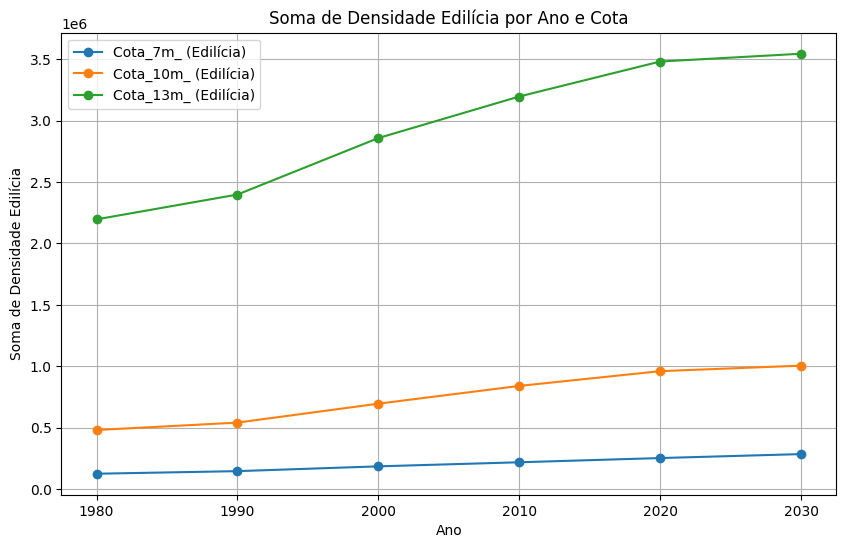

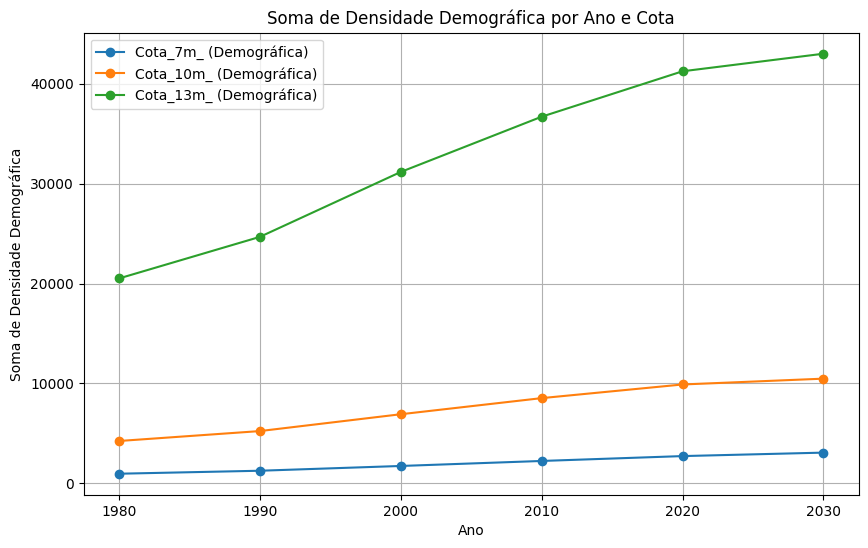

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo Excel
file_path = '/content/soma_densidades_por_ano_cota.xlsx'
df_somas = pd.read_excel(file_path)

# Plotando os dados para Densidade Edilícia e Demográfica, separadamente por cota e ano

# Definir as cotas únicas
cotas = df_somas['Cota'].unique()

# Criar o gráfico para Densidade Edilícia
plt.figure(figsize=(10, 6))
for cota in cotas:
    # Filtrar os dados para a cota específica
    df_cota = df_somas[df_somas['Cota'] == cota]
    plt.plot(df_cota['Ano'], df_cota['Soma_Densidade_Edilicia'], label=f'{cota} (Edilícia)', marker='o')

plt.title('Soma de Densidade Edilícia por Ano e Cota')
plt.xlabel('Ano')
plt.ylabel('Soma de Densidade Edilícia')
plt.legend()
plt.grid(True)
plt.show()

# Criar o gráfico para Densidade Demográfica
plt.figure(figsize=(10, 6))
for cota in cotas:
    # Filtrar os dados para a cota específica
    df_cota = df_somas[df_somas['Cota'] == cota]
    plt.plot(df_cota['Ano'], df_cota['Soma_Densidade_Demografica'], label=f'{cota} (Demográfica)', marker='o')

plt.title('Soma de Densidade Demográfica por Ano e Cota')
plt.xlabel('Ano')
plt.ylabel('Soma de Densidade Demográfica')
plt.legend()
plt.grid(True)
plt.show()


# Teste de Regressão Linear

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# Carregar o arquivo Excel
file_path = '/content/soma_densidades_por_ano_cota.xlsx'
df_somas = pd.read_excel(file_path)

# Definir as cotas únicas
cotas = df_somas['Cota'].unique()

# Função para realizar e exibir a regressão linear
def regressao_linear(X, y):
    # Regressão linear
    model = LinearRegression()
    model.fit(X, y)
    coef = model.coef_[0]
    intercept = model.intercept_
    return coef, intercept

# Definir os anos como uma matriz
X = df_somas['Ano'].values.reshape(-1, 1)

# Iterar pelas cotas para encontrar a função de regressão linear de cada uma
for cota in cotas:
    df_cota = df_somas[df_somas['Cota'] == cota]

    # Regressão linear para Densidade Edilícia
    y_edilicia = df_cota['Soma_Densidade_Edilicia'].values
    coef_edilicia, intercept_edilicia = regressao_linear(df_cota['Ano'].values.reshape(-1, 1), y_edilicia)
    print(f'Função linear para Densidade Edilícia ({cota}): y = {coef_edilicia:.2f} * x + {intercept_edilicia:.2f}')

    # Regressão linear para Densidade Demográfica
    y_demografica = df_cota['Soma_Densidade_Demografica'].values
    coef_demografica, intercept_demografica = regressao_linear(df_cota['Ano'].values.reshape(-1, 1), y_demografica)
    print(f'Função linear para Densidade Demográfica ({cota}): y = {coef_demografica:.2f} * x + {intercept_demografica:.2f}')


Função linear para Densidade Edilícia (Cota_7m_): y = 3291.11 * x + -6395967.12
Função linear para Densidade Demográfica (Cota_7m_): y = 44.19 * x + -86598.95
Função linear para Densidade Edilícia (Cota_10m_): y = 11488.89 * x + -22280866.86
Função linear para Densidade Demográfica (Cota_10m_): y = 133.80 * x + -260711.86
Função linear para Densidade Edilícia (Cota_13m_): y = 29511.47 * x + -56224586.49
Função linear para Densidade Demográfica (Cota_13m_): y = 479.44 * x + -928390.94


Comparando as diferentes cotas:
A inclinação (coeficiente 𝑎 ) aumenta conforme a cota aumenta:
Para a Cota_7m_, a densidade edilícia aumenta em 3196,25 unidades por ano.
Para a Cota_10m_, o crescimento anual é mais rápido, com 11076,02 unidades por ano.
Para a Cota_13m_, o crescimento é ainda mais acentuado, com 28544,65 unidades por ano.
Isso significa que, nas cotas mais altas, o crescimento da densidade é maior ao longo do tempo.

# Teste de Regressão Polinomial

In [ ]:
import pandas as pd
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt

# Carregar o arquivo Excel
file_path = '/content/soma_densidades_por_ano_cota.xlsx'
df_somas = pd.read_excel(file_path)

# Definir as cotas únicas
cotas = df_somas['Cota'].unique()

# Função para realizar e exibir a regressão polinomial de grau 2
def regressao_polinomial(X, y, grau=2):
    # Ajustar o polinômio de grau 2
    p = Polynomial.fit(X, y, deg=grau)
    return p.convert().coef

# Iterar pelas cotas para encontrar a função polinomial de cada uma
for cota in cotas:
    df_cota = df_somas[df_somas['Cota'] == cota]

    # Regressão polinomial para Densidade Edilícia
    X = df_cota['Ano'].values
    y_edilicia = df_cota['Soma_Densidade_Edilicia'].values
    coef_edilicia = regressao_polinomial(X, y_edilicia)
    print(f'Função polinomial para Densidade Edilícia ({cota}): y = {coef_edilicia[0]:.2f} + {coef_edilicia[1]:.2f}x + {coef_edilicia[2]:.2f}x²')

    # Regressão polinomial para Densidade Demográfica
    y_demografica = df_cota['Soma_Densidade_Demografica'].values
    coef_demografica = regressao_polinomial(X, y_demografica)
    print(f'Função polinomial para Densidade Demográfica ({cota}): y = {coef_demografica[0]:.2f} + {coef_demografica[1]:.2f}x + {coef_demografica[2]:.2f}x²')


Função polinomial para Densidade Edilícia (Cota_7m_): y = 20707802.69 + -23747.04x + 6.74x²
Função polinomial para Densidade Demográfica (Cota_7m_): y = 117972.05 + -159.89x + 0.05x²
Função polinomial para Densidade Edilícia (Cota_10m_): y = -175516690.57 + 164353.67x + -38.12x²
Função polinomial para Densidade Demográfica (Cota_10m_): y = -2648644.77 + 2515.95x + -0.59x²
Função polinomial para Densidade Edilícia (Cota_13m_): y = -1055656627.63 + 1026523.50x + -248.63x²
Função polinomial para Densidade Demográfica (Cota_13m_): y = -15156042.35 + 14672.64x + -3.54x²


O ajuste polinomial sugere que o crescimento da densidade, tanto edilícia quanto demográfica, começa rápido e depois desacelera ao longo do tempo.
A desaceleração é mais acentuada para as cotas mais altas (10m e 13m), o que pode refletir limitações físicas ou saturações de ocupação à medida que as cotas aumentam.

A curvatura negativa (−𝑥2−x 2 ) sugere que o crescimento é rápido no início e desacelera mais tarde, o que é um padrão típico em muitos contextos, como crescimento urbano ou populacional.

RESULTADOS PRÁTICOS

A regressão polinomial mostrou que para cotas mais altas (como 10m e 13m), há uma desaceleração acentuada no crescimento das densidades, o que pode refletir barreiras ou limitações físicas, saturação de áreas, ou outros fenômenos.

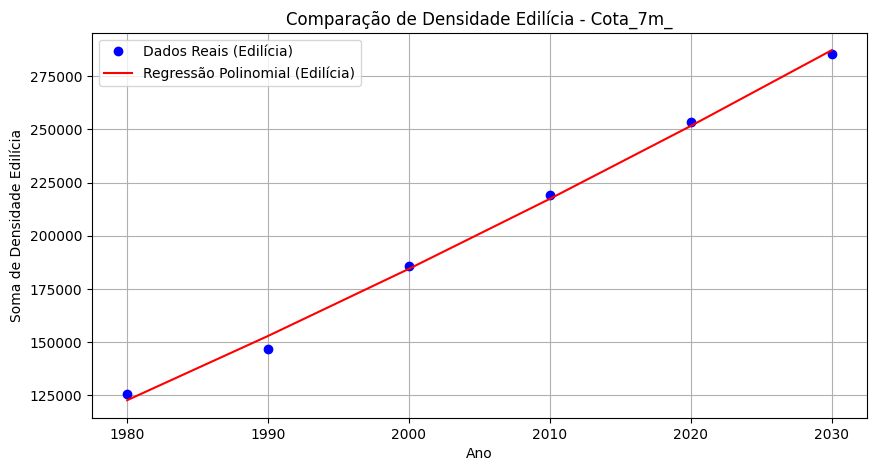

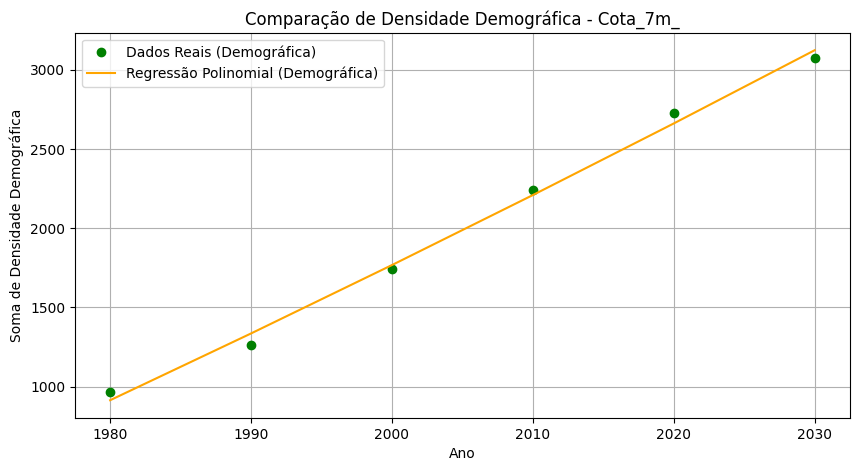

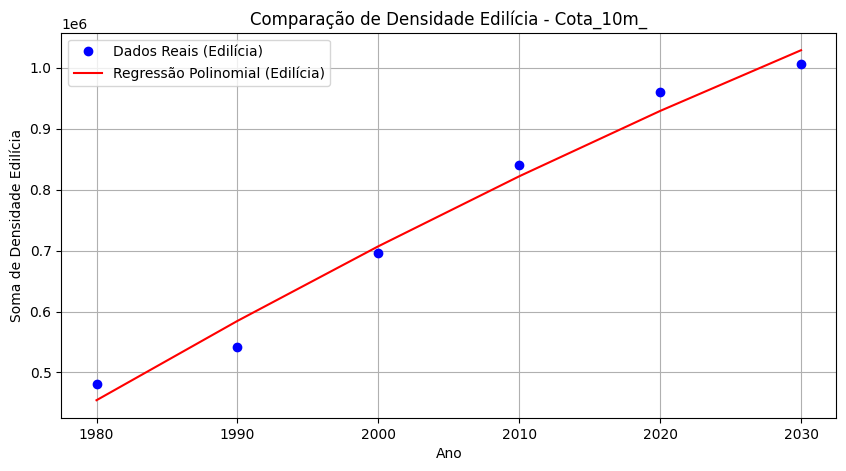

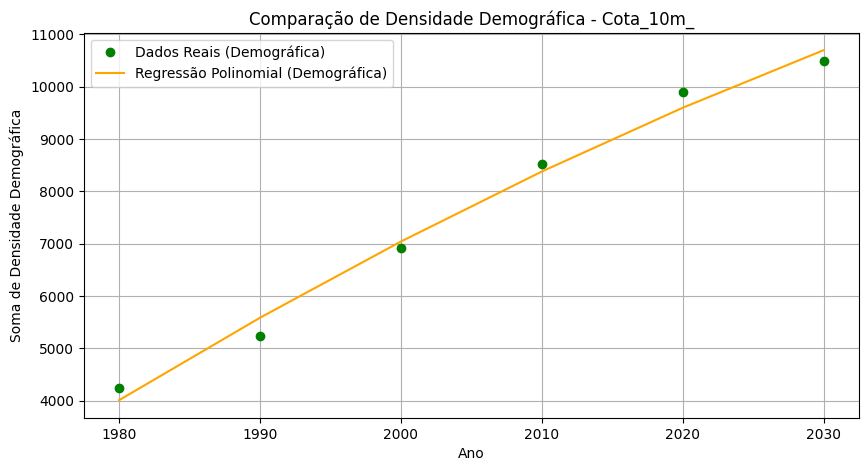

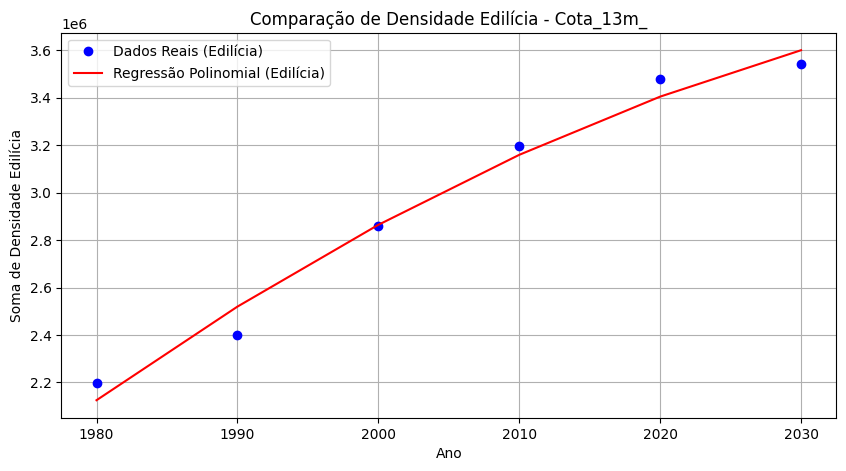

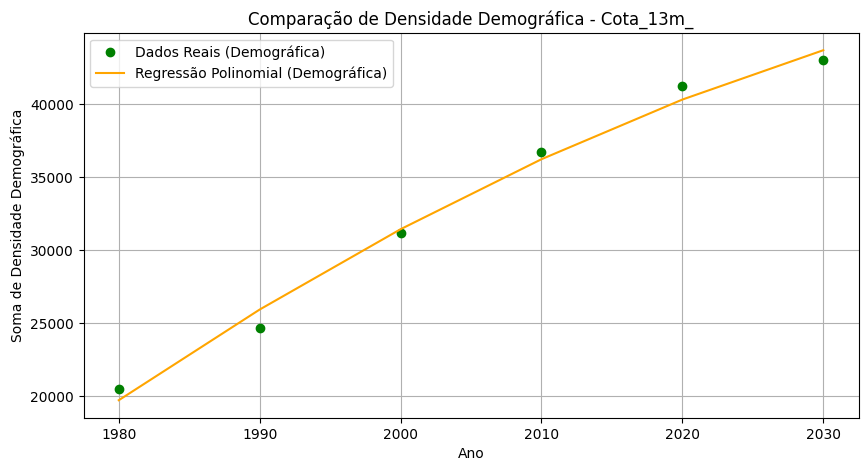

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# Carregar o arquivo Excel
file_path = '/content/soma_densidades_por_ano_cota.xlsx'
df_somas = pd.read_excel(file_path)

# Definir as cotas únicas
cotas = df_somas['Cota'].unique()

# Função para realizar a regressão polinomial e calcular os valores previstos
def regressao_polinomial(X, y, grau=2):
    # Ajustar o polinômio de grau 2
    p = Polynomial.fit(X, y, deg=grau)
    return p.convert()

# Criar gráficos para comparar os dados reais e as previsões
for cota in cotas:
    df_cota = df_somas[df_somas['Cota'] == cota]

    # Regressão polinomial para Densidade Edilícia
    X = df_cota['Ano'].values
    y_edilicia = df_cota['Soma_Densidade_Edilicia'].values
    polinomio_edilicia = regressao_polinomial(X, y_edilicia)

    # Previsões da densidade edilícia usando a função polinomial
    y_pred_edilicia = polinomio_edilicia(X)

    # Plotar os dados reais e as previsões da regressão polinomial para Densidade Edilícia
    plt.figure(figsize=(10, 5))
    plt.plot(X, y_edilicia, 'o', label='Dados Reais (Edilícia)', color='blue')
    plt.plot(X, y_pred_edilicia, '-', label='Regressão Polinomial (Edilícia)', color='red')
    plt.title(f'Comparação de Densidade Edilícia - {cota}')
    plt.xlabel('Ano')
    plt.ylabel('Soma de Densidade Edilícia')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Regressão polinomial para Densidade Demográfica
    y_demografica = df_cota['Soma_Densidade_Demografica'].values
    polinomio_demografica = regressao_polinomial(X, y_demografica)

    # Previsões da densidade demográfica usando a função polinomial
    y_pred_demografica = polinomio_demografica(X)

    # Plotar os dados reais e as previsões da regressão polinomial para Densidade Demográfica
    plt.figure(figsize=(10, 5))
    plt.plot(X, y_demografica, 'o', label='Dados Reais (Demográfica)', color='green')
    plt.plot(X, y_pred_demografica, '-', label='Regressão Polinomial (Demográfica)', color='orange')
    plt.title(f'Comparação de Densidade Demográfica - {cota}')
    plt.xlabel('Ano')
    plt.ylabel('Soma de Densidade Demográfica')
    plt.legend()
    plt.grid(True)
    plt.show()



# Inflexão da curva --> A Partir da Derivada

A "inflexão" na curva acontece quando a derivada da função muda de sinal, ou seja, quando a taxa de crescimento da densidade (edilícia ou demográfica) passa a diminuir ao invés de crescer. Para uma equação polinomial de grau 2, a inflexão ocorre quando a derivada da função é igual a zero.

Para uma equação polinomial de grau 2:

𝑦 =𝑎𝑥2+𝑏𝑥+𝑐
y=ax 2 +bx+c
A derivada da função é dada por:

𝑦′=2𝑎𝑥+𝑏
y ′ =2ax+b
A inflexão acontece quando
𝑦′=0
y ′ =0,

ou seja, resolvemos a equação:

2𝑎𝑥+𝑏=0
ou
𝑥=−𝑏2𝑎2ax+b=0
ou
x=−2ab​

Isso nos dará o ano em que ocorre a inflexão (ou seja, quando a densidade atinge o pico e começa a diminuir).

In [ ]:
import pandas as pd
from numpy.polynomial import Polynomial

# Carregar o arquivo Excel
file_path = '/content/soma_densidades_por_ano_cota.xlsx'
df_somas = pd.read_excel(file_path)

# Definir as cotas únicas
cotas = df_somas['Cota'].unique()

# Função para realizar a regressão polinomial e calcular os coeficientes
def regressao_polinomial(X, y, grau=2):
    # Ajustar o polinômio de grau 2
    p = Polynomial.fit(X, y, deg=grau)
    return p.convert().coef  # Retorna os coeficientes do polinômio

# Iterar pelas cotas para encontrar o ponto de inflexão para Densidade Edilícia e Demográfica
for cota in cotas:
    df_cota = df_somas[df_somas['Cota'] == cota]

    # Regressão polinomial para Densidade Edilícia
    X = df_cota['Ano'].values
    y_edilicia = df_cota['Soma_Densidade_Edilicia'].values
    coef_edilicia = regressao_polinomial(X, y_edilicia)

    # Encontrar o ano de inflexão para Densidade Edilícia (x = -b/2a)
    a_edilicia = coef_edilicia[2]
    b_edilicia = coef_edilicia[1]
    if a_edilicia != 0:  # Garantir que haja um termo quadrático
        ano_inflexao_edilicia = -b_edilicia / (2 * a_edilicia)
        print(f'Inflexão para Densidade Edilícia ({cota}): Ano {ano_inflexao_edilicia:.0f}')

    # Regressão polinomial para Densidade Demográfica
    y_demografica = df_cota['Soma_Densidade_Demografica'].values
    coef_demografica = regressao_polinomial(X, y_demografica)

    # Encontrar o ano de inflexão para Densidade Demográfica (x = -b/2a)
    a_demografica = coef_demografica[2]
    b_demografica = coef_demografica[1]
    if a_demografica != 0:  # Garantir que haja um termo quadrático
        ano_inflexao_demografica = -b_demografica / (2 * a_demografica)
        print(f'Inflexão para Densidade Demográfica ({cota}): Ano {ano_inflexao_demografica:.0f}')


Inflexão para Densidade Edilícia (Cota_7m_): Ano 1761
Inflexão para Densidade Demográfica (Cota_7m_): Ano 1571
Inflexão para Densidade Edilícia (Cota_10m_): Ano 2156
Inflexão para Densidade Demográfica (Cota_10m_): Ano 2118
Inflexão para Densidade Edilícia (Cota_13m_): Ano 2064
Inflexão para Densidade Demográfica (Cota_13m_): Ano 2073
